# M4/T6: GraphRAG на HotpotQA Distractor

Цель работы — проверить, помогает ли граф связей между документами восстанавливать полную multi-hop support chain в `HotpotQA distractor` и превращается ли это улучшение retrieval в более точный финальный ответ.

Самописный `GraphRAG` здесь оправдан по трем причинам.

- В `HotpotQA distractor` у каждого вопроса уже есть компактный набор из `10` документов-кандидатов. Значит, задача состоит не в глобальном поиске по большой базе, а в правильном выборе связанной пары документов внутри локального подграфа.
- Обычный dense top-k хорошо находит один очевидно релевантный документ, но часто теряет второй, bridge-документ. Именно этот тип ошибки и должен исправлять граф.
- Локальный граф по десяти документам делает эксперимент контролируемым: у baseline и у graph-версии одинаковый пул кандидатов, одинаковый retriever и одинаковый бюджет `top-2`; меняется только способ выбора второго документа.

Готовые `GraphRAG`-фреймворки сознательно не использовались. Для этой постановки они слишком тяжеловесны: обычно они требуют отдельного ingestion pipeline, entity extraction, chunking, graph storage, набора эвристик для edge construction и дополнительной настройки prompt-слоя. В большой production-задаче это может быть оправдано, но в `HotpotQA distractor` такая инфраструктура только затрудняет интерпретацию результата. Здесь важнее изолированно проверить узкую гипотезу: помогает ли граф выбрать второй supporting document при фиксированном наборе кандидатов.

Работа построена как последовательность из двух проверок.

1. Сначала оценивается retrieval: удалось ли восстановить оба supporting documents.
2. Затем поверх тех же двух документов запускается answer stage и измеряется `Exact Match`.

Такая схема нужна, чтобы отдельно проверить полезность графа как механизма retrieval и не смешивать ее с ограничениями answer-модели.


In [11]:
from __future__ import annotations

import json
import os
import re
import unicodedata
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.utils import logging as hf_logging

SEED = 42
RETRIEVAL_N = 300
ANSWER_N = 100
DATA_ARCHIVE_CANDIDATES = [
    Path("M4/T6/data/data_ids_april7.zip"),
    Path("data/data_ids_april7.zip"),
]
DATA_ARCHIVE = next(
    (candidate for candidate in DATA_ARCHIVE_CANDIDATES if candidate.exists()), DATA_ARCHIVE_CANDIDATES[0]
)
DATA_SPLIT = "dev.json"
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
ANSWER_MODEL = "/home/krv/qwen"
ANSWER_MAX_INPUT_TOKENS = 2048
ANSWER_MAX_NEW_TOKENS = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


## 1. Задача, данные и методика проверки

Используется `HotpotQA` в `distractor`-постановке. Для каждого вопроса дан список из `10` документов, среди которых ровно `2` являются supporting documents. Вопрос считается multi-hop, потому что правильный ответ обычно требует информации сразу из обоих документов.

В этой работе проверяется следующая гипотеза: если после выбора первого релевантного документа использовать граф междокументных связей, то второй supporting document будет находиться чаще, чем при обычном dense top-2 retrieval.

Проверка разделена на два уровня.

- `Retrieval evaluation` проводится на `1000` вопросах. Здесь важно понять, улучшает ли граф именно восстановление support chain.
- `Answer evaluation` проводится на `300` вопросах. Здесь проверяется, превращается ли выигрыш в retrieval в выигрыш по конечной метрике ответа.

Используются две группы метрик.

- `both_support@2` — попали ли оба supporting documents в два выбранных документа.
- `one_support@2` — найден ли хотя бы один supporting document.
- `support_recall@2` — средняя доля support chain, покрытая двумя выбранными документами.
- `EM` — точное совпадение финального ответа с эталоном.

Такое разделение методики принципиально: retrieval-метрики показывают, решает ли граф именно задачу поиска второго документа, а `EM` показывает, достаточно ли этого выигрыша для улучшения end-to-end QA.


In [12]:
def normalize_hotpot_row(row: dict) -> dict:
    context_titles = [title for title, _ in row["context"]]
    context_sentences = [sentences for _, sentences in row["context"]]
    support_titles = [title for title, _ in row["supporting_facts"]]
    support_sent_ids = [sent_id for _, sent_id in row["supporting_facts"]]
    return {
        "_id": row.get("_id"),
        "question": row["question"],
        "answer": row["answer"],
        "type": row.get("type"),
        "context": {
            "title": context_titles,
            "sentences": context_sentences,
        },
        "supporting_facts": {
            "title": support_titles,
            "sent_id": support_sent_ids,
        },
    }


def load_hotpot_subset(limit: int) -> list[dict]:
    if DATA_ARCHIVE.exists():
        with zipfile.ZipFile(DATA_ARCHIVE) as zf:
            with zf.open(DATA_SPLIT) as fp:
                rows = json.load(fp)
        return [normalize_hotpot_row(row) for row in rows[:limit]]

    dataset = load_dataset("hotpotqa/hotpot_qa", "distractor", split=f"validation[:{limit}]")
    return [dataset[i] for i in range(len(dataset))]


hotpot_rows = load_hotpot_subset(max(RETRIEVAL_N, ANSWER_N))
dataset_retr = hotpot_rows[:RETRIEVAL_N]
dataset_ans = hotpot_rows[:ANSWER_N]

source_name = str(DATA_ARCHIVE) if DATA_ARCHIVE.exists() else "hotpotqa/hotpot_qa:distractor"
print(f"Source: {source_name}")
print(f"Retrieval subset: {len(dataset_retr)} вопросов")
print(f"Answer subset: {len(dataset_ans)} вопросов")
print(dataset_retr[0]["question"])
print(dataset_retr[0]["supporting_facts"])


Source: data/data_ids_april7.zip
Retrieval subset: 300 вопросов
Answer subset: 100 вопросов
Who is the mother of the director of film Polish-Russian War (Film)?
{'title': ['Polish-Russian War (film)', 'Xawery Żuławski'], 'sent_id': [1, 2]}


## 2. Модели и компоненты

Для dense retrieval используется `sentence-transformers/all-MiniLM-L6-v2`. Эта модель кодирует вопрос и каждый из десяти документов, после чего baseline и graph-версия работают уже с одним и тем же набором dense similarity scores.

Для answer stage используется `Qwen2.5-1.5B-Instruct`, загруженная локально с сервера. Модель получает вопрос и компактный контекст из двух выбранных документов и генерирует короткий финальный ответ.

Графовая часть не использует внешнюю базу знаний. Граф строится заново для каждого вопроса только по его десяти кандидатным документам. Это важно для чистоты эксперимента: вся разница между подходами сосредоточена в логике выбора документов, а не во внешних источниках информации.


In [13]:
hf_logging.set_verbosity_error()
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
np.random.seed(SEED)
torch.manual_seed(SEED)

retriever_model = SentenceTransformer(EMBED_MODEL, device=DEVICE, local_files_only=True)


def load_answer_model() -> tuple[AutoTokenizer, AutoModelForCausalLM]:
    tokenizer = AutoTokenizer.from_pretrained(ANSWER_MODEL, local_files_only=True)
    model = (
        AutoModelForCausalLM.from_pretrained(
            ANSWER_MODEL,
            local_files_only=True,
            torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
            low_cpu_mem_usage=True,
        )
        .to(DEVICE)
        .eval()
    )
    return tokenizer, model


answer_tokenizer, answer_model = load_answer_model()
print(f"Device: {DEVICE}")
print(f"Answer model: {ANSWER_MODEL}")


def normalize(text: str) -> str:
    text = unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("ascii")
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def doc_text(title: str, sentences: list[str]) -> str:
    return f"title: {title}. " + " ".join(sentences)


def support_titles(row) -> list[str]:
    return sorted(set(row["supporting_facts"]["title"]))


def exact_match(pred: str, gold: str) -> int:
    return int(normalize(pred) == normalize(gold))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Device: cuda
Answer model: /home/krv/qwen


## 3. Пайплайн baseline и GraphRAG

### Baseline

`Baseline` использует самый прямой сценарий retrieval.

1. Вопрос и документы кодируются dense retriever-моделью.
2. Документы сортируются по cosine similarity к вопросу.
3. В answer stage передаются два документа с максимальным dense score.

### GraphRAG

`GraphRAG` использует тот же первый шаг, но меняет логику добора второго документа.

1. По dense similarity выбирается лучший seed-документ.
2. По десяти документам строится локальный граф.
3. Между документами добавляются два типа ребер:
- `mention edge`: текст документа `A` явно упоминает заголовок документа `B`.
- `semantic edge`: документы близки друг к другу по эмбеддингам.
4. Для каждого кандидата на второй документ считается итоговый score:
   `0.45 * dense + 0.40 * direct_edge + 0.15 * two_hop`.
5. В answer stage передаются seed-документ и лучший кандидат по этому score.

Таким образом, граф используется не как декоративное представление, а как механизм выбора второго документа в multi-hop цепочке.


In [14]:
def baseline_retrieve(
    question: str, titles: list[str], doc_embs: np.ndarray, top_k: int = 2
) -> tuple[list[str], np.ndarray]:
    q_emb = retriever_model.encode([question], normalize_embeddings=True)[0]
    dense = doc_embs @ q_emb
    order = np.argsort(dense)[::-1]
    return [titles[i] for i in order[:top_k]], dense


def build_document_graph(titles: list[str], texts: list[str], doc_embs: np.ndarray) -> nx.Graph:
    graph = nx.Graph()
    title_norms = {title: normalize(title) for title in titles}
    for title in titles:
        graph.add_node(title)

    for i, src in enumerate(titles):
        src_text = " " + normalize(texts[i]) + " "
        for j, dst in enumerate(titles):
            if i == j:
                continue
            dst_title = " " + title_norms[dst] + " "
            if len(title_norms[dst]) >= 4 and dst_title in src_text:
                prev = graph.get_edge_data(src, dst, {"weight": 0.0})["weight"]
                graph.add_edge(src, dst, weight=max(prev, 1.0), edge_type="mention")

    sim = doc_embs @ doc_embs.T
    for i, src in enumerate(titles):
        neighbors = np.argsort(sim[i])[::-1][1:4]
        for j in neighbors:
            dst = titles[j]
            weight = float(sim[i, j])
            if weight > 0.30:
                prev = graph.get_edge_data(src, dst, {"weight": 0.0})["weight"]
                graph.add_edge(src, dst, weight=max(prev, weight), edge_type="semantic")

    return graph


def graph_retrieve(
    question: str, titles: list[str], texts: list[str], doc_embs: np.ndarray
) -> tuple[list[str], nx.Graph, str]:
    baseline_docs, dense = baseline_retrieve(question, titles, doc_embs, top_k=3)
    seed = baseline_docs[0]
    graph = build_document_graph(titles, texts, doc_embs)
    seed_neighbors = set(graph.neighbors(seed)) if seed in graph else set()

    candidate_scores = []
    for idx, title in enumerate(titles):
        if title == seed:
            continue
        direct_edge = graph.get_edge_data(seed, title, {"weight": 0.0}).get("weight", 0.0)
        two_hop = 0.0
        for middle in seed_neighbors:
            if graph.has_edge(middle, title):
                two_hop = max(two_hop, min(graph[seed][middle]["weight"], graph[middle][title]["weight"]))
        score = 0.45 * float(dense[idx]) + 0.40 * direct_edge + 0.15 * two_hop
        candidate_scores.append((score, title, direct_edge, two_hop, float(dense[idx])))

    candidate_scores.sort(reverse=True)
    second = candidate_scores[0][1] if candidate_scores else baseline_docs[1]
    return [seed, second], graph, seed

## 4. Методика retrieval-оценки

Сравнение baseline и `GraphRAG` сделано в одинаковых условиях.

- Для каждого вопроса обе системы видят один и тот же набор из `10` документов.
- Обе системы используют один и тот же dense retriever.
- Обе системы имеют одинаковый бюджет `top-2`.
- Единственное различие — способ выбора второго документа после нахождения первого релевантного кандидата.

Главная retrieval-метрика в этой задаче — `both_support@2`. Она напрямую отвечает на вопрос, удалось ли системе восстановить полную support chain, то есть найти оба документа, необходимые для multi-hop reasoning.

Метрики `one_support@2` и `support_recall@2` нужны как вспомогательные.

- `one_support@2` показывает, не потеряла ли система базовую способность находить хотя бы один очевидный релевантный документ.
- `support_recall@2` показывает, насколько полно два выбранных документа покрывают gold support chain в среднем.

Если граф полезен содержательно, он должен прежде всего поднимать `both_support@2`, а не просто переупорядочивать документы без выигрыша в полноте support chain.


In [15]:
retrieval_rows = []
for row in dataset_retr:
    titles = row["context"]["title"]
    sentences = row["context"]["sentences"]
    texts = [doc_text(title, sents) for title, sents in zip(titles, sentences)]
    doc_embs = retriever_model.encode(texts, normalize_embeddings=True)
    support = set(support_titles(row))

    baseline_docs, _ = baseline_retrieve(row["question"], titles, doc_embs)
    graph_docs, graph, seed = graph_retrieve(row["question"], titles, texts, doc_embs)

    retrieval_rows.append(
        {
            "question": row["question"],
            "answer": row["answer"],
            "support_titles": sorted(support),
            "baseline_docs": baseline_docs,
            "graph_docs": graph_docs,
            "baseline_both_support": int(support.issubset(set(baseline_docs))),
            "graph_both_support": int(support.issubset(set(graph_docs))),
            "baseline_one_support": int(len(support & set(baseline_docs)) >= 1),
            "graph_one_support": int(len(support & set(graph_docs)) >= 1),
            "baseline_support_recall": len(support & set(baseline_docs)) / len(support),
            "graph_support_recall": len(support & set(graph_docs)) / len(support),
            "graph_edges": graph.number_of_edges(),
            "seed_doc": seed,
        }
    )

retrieval_df = pd.DataFrame(retrieval_rows)
retrieval_df.head(10)

,question,answer,support_titles,baseline_docs,graph_docs,baseline_both_support,graph_both_support,baseline_one_support,graph_one_support,baseline_support_recall,graph_support_recall,graph_edges,seed_doc
0,Who is the mother of the director of film Poli...,Małgorzata Braunek,"[Polish-Russian War (film), Xawery Żuławski]","[Polish-Russian War (film), Xawery Żuławski]","[Polish-Russian War (film), Xawery Żuławski]",1,1,1,1,1.00,1.00,12,Polish-Russian War (film)
1,"Which film came out first, Blind Shaft or The ...",The Mask Of Fu Manchu,"[Blind Shaft, The Mask of Fu Manchu]","[The Mask of Fu Manchu, The Mysterious Dr. Fu ...","[The Mask of Fu Manchu, The Face of Fu Manchu]",0,0,1,1,0.50,0.50,21,The Mask of Fu Manchu
2,"When did John V, Prince Of Anhalt-Zerbst's fat...",12 June 1516,"[Ernest I, Prince of Anhalt-Dessau, John V, Pr...","[John VI, Prince of Anhalt-Zerbst, John II, Pr...","[John VI, Prince of Anhalt-Zerbst, John V, Pri...",0,0,0,1,0.00,0.50,21,"John VI, Prince of Anhalt-Zerbst"
3,What is the award that the director of film We...,Myanmar Motion Picture Academy Awards,[Wearing Velvet Slippers under a Golden Umbrel...,[Wearing Velvet Slippers under a Golden Umbrel...,[Wearing Velvet Slippers under a Golden Umbrel...,0,1,1,1,0.50,1.00,10,Wearing Velvet Slippers under a Golden Umbrella
4,Where was the director of film Ronnie Rocket b...,"Missoula, Montana","[David Lynch, Ronnie Rocket]","[Ronnie Rocket, Ian Barry (director)]","[Ronnie Rocket, David Lynch]",0,1,1,1,0.50,1.00,13,Ronnie Rocket
5,Who is Charles Bretagne Marie De La Trémoille'...,Charles Armand René de La Trémoille,"[Charles Bretagne Marie de La Trémoille, Jean ...","[Charles Bretagne Marie de La Trémoille, Jean ...","[Charles Bretagne Marie de La Trémoille, Jean ...",1,1,1,1,1.00,1.00,20,Charles Bretagne Marie de La Trémoille
6,Where was the father of Ștefan I. Nenițescu born?,Galați,"[Ioan S. Nenițescu, Ștefan I. Nenițescu]","[Ioan S. Nenițescu, Ștefan I. Nenițescu]","[Ioan S. Nenițescu, Ștefan I. Nenițescu]",1,1,1,1,1.00,1.00,13,Ioan S. Nenițescu
7,Are North Marion High School (Oregon) and Seou...,no,"[North Marion High School (Oregon), Seoul High...","[Seoul High School, North Marion High School (...","[Seoul High School, Marion High School (Kansas)]",1,0,1,1,1.00,0.50,23,Seoul High School
8,Which film has the director who was born later...,El Extraño Viaje,"[Charles Saunders (director), El extraño viaje...","[El extraño viaje, A Lover in Pawn]","[El extraño viaje, Rafaela Aparicio]",0,0,1,1,0.25,0.25,12,El extraño viaje
9,Who is the maternal grandfather of Antiochus X...,Ptolemy IX Lathyros,"[Antiochus X Eusebes, Cleopatra IV of Egypt]","[Antiochus X Eusebes, Abd al-Muttalib]","[Antiochus X Eusebes, Laodice of the Sameans]",0,0,1,1,0.50,0.50,11,Antiochus X Eusebes


In [16]:
retrieval_summary = pd.DataFrame(
    {
        "baseline": [
            retrieval_df["baseline_both_support"].mean(),
            retrieval_df["baseline_one_support"].mean(),
            retrieval_df["baseline_support_recall"].mean(),
        ],
        "graph": [
            retrieval_df["graph_both_support"].mean(),
            retrieval_df["graph_one_support"].mean(),
            retrieval_df["graph_support_recall"].mean(),
        ],
    },
    index=["both_support@2", "one_support@2", "support_recall@2"],
)
retrieval_summary.round(3)

,baseline,graph
both_support@2,0.28,0.350
one_support@2,0.96,0.953
support_recall@2,0.61,0.637


In [17]:
improved_cases = retrieval_df[(retrieval_df["graph_both_support"] > retrieval_df["baseline_both_support"])][
    ["question", "support_titles", "baseline_docs", "graph_docs", "seed_doc", "graph_edges"]
]
print(f"Число кейсов, где GraphRAG исправил baseline: {len(improved_cases)}")
improved_cases.head(8)

Число кейсов, где GraphRAG исправил baseline: 53


,question,support_titles,baseline_docs,graph_docs,seed_doc,graph_edges
3,What is the award that the director of film We...,[Wearing Velvet Slippers under a Golden Umbrel...,[Wearing Velvet Slippers under a Golden Umbrel...,[Wearing Velvet Slippers under a Golden Umbrel...,Wearing Velvet Slippers under a Golden Umbrella,10
4,Where was the director of film Ronnie Rocket b...,"[David Lynch, Ronnie Rocket]","[Ronnie Rocket, Ian Barry (director)]","[Ronnie Rocket, David Lynch]",Ronnie Rocket,13
13,Where was the director of film Thomas Jefferso...,"[Ken Burns, Thomas Jefferson (film)]","[Thomas Jefferson (film), Atiba Jefferson]","[Thomas Jefferson (film), Ken Burns]",Thomas Jefferson (film),19
15,Where was the place of death of the director o...,"[Beat Girl, Edmond T. Gréville]","[Beat Girl, Kim Sung-su (director)]","[Beat Girl, Edmond T. Gréville]",Beat Girl,10
21,What nationality is the director of film World...,"[Eric Mueller, World and Time Enough]","[World and Time Enough, John Farrell (business...","[World and Time Enough, Eric Mueller]",World and Time Enough,12
28,Where was the place of death of Anastasia Of S...,"[Anastasia of Serbia, Stefan Nemanja]","[Anastasia of Serbia, Princess Helen of Serbia]","[Anastasia of Serbia, Stefan Nemanja]",Anastasia of Serbia,21
35,Who is the paternal grandfather of Taj Al-Dawla?,"['Adud al-Dawla, Taj al-Dawla]","[Taj al-Dawla, Ziyar ibn Shahrakuya]","[Taj al-Dawla, 'Adud al-Dawla]",Taj al-Dawla,22
44,Where was the husband of Caterina Visconti born?,"[Caterina Visconti, Gian Galeazzo Visconti]","[Caterina Visconti, Giacomo Feo]","[Caterina Visconti, Gian Galeazzo Visconti]",Caterina Visconti,14


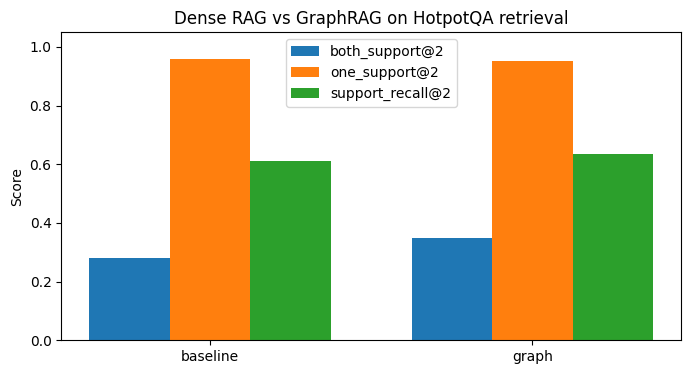

In [18]:
plot_df = retrieval_summary.T.reset_index().rename(columns={"index": "method"})
fig, ax = plt.subplots(figsize=(8, 4))
width = 0.25
x = np.arange(len(plot_df))
ax.bar(x - width, plot_df["both_support@2"], width=width, label="both_support@2")
ax.bar(x, plot_df["one_support@2"], width=width, label="one_support@2")
ax.bar(x + width, plot_df["support_recall@2"], width=width, label="support_recall@2")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["method"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Dense RAG vs GraphRAG on HotpotQA retrieval")
ax.legend()
plt.show()

## 5. Answer stage и end-to-end проверка

После retrieval обе системы передают в answer stage ровно два документа. Дальше используется одна и та же answer-модель и один и тот же формат prompt. Значит, различие в `EM` можно интерпретировать как следствие различия в качестве retrieval.

Эта проверка нужна по двум причинам.

- Улучшение retrieval еще не гарантирует улучшение финального ответа: answer-модель может не справиться с объединением информации из двух документов.
- Если при одинаковой answer-модели `GraphRAG` дает более высокий `EM`, это означает, что граф улучшил не только промежуточные retrieval-метрики, но и полезность контекста для конечной QA-задачи.

Именно поэтому в ноутбуке сначала оценивается retrieval отдельно, а затем проводится end-to-end измерение `EM`.


In [19]:
def build_answer_prompt(question: str, selected_titles: list[str], title_to_text: dict[str, str]) -> str:
    sections = []
    for idx, title in enumerate(selected_titles, start=1):
        sections.append(f"Document {idx}\nTitle: {title}\nText: {title_to_text[title]}")
    docs_block = "\n\n".join(sections)
    return (
        "Use only the provided documents to answer the question. "
        "Return only the final short answer without explanation. "
        "If the answer is yes/no, output exactly yes or no.\n\n"
        f"Question: {question}\n\n"
        f"Documents:\n{docs_block}"
    )


def answer_question(question: str, selected_titles: list[str], title_to_text: dict[str, str]) -> str:
    prompt = build_answer_prompt(question, selected_titles, title_to_text)
    messages = [
        {"role": "system", "content": "You are a careful QA model for multi-hop questions."},
        {"role": "user", "content": prompt},
    ]
    rendered = answer_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = answer_tokenizer(
        rendered,
        return_tensors="pt",
        truncation=True,
        max_length=ANSWER_MAX_INPUT_TOKENS,
    ).to(DEVICE)

    with torch.inference_mode():
        outputs = answer_model.generate(
            **inputs,
            max_new_tokens=ANSWER_MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=answer_tokenizer.eos_token_id,
            eos_token_id=answer_tokenizer.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1] :]
    answer = answer_tokenizer.decode(generated, skip_special_tokens=True).strip()
    answer = answer.splitlines()[0].strip()
    answer = re.sub(r"^(answer|final answer)\s*:\s*", "", answer, flags=re.I)
    return answer


answer_rows = []
for row in dataset_ans:
    titles = row["context"]["title"]
    sentences = row["context"]["sentences"]
    texts = [doc_text(title, sents) for title, sents in zip(titles, sentences)]
    title_to_text = {title: text for title, text in zip(titles, texts)}
    doc_embs = retriever_model.encode(texts, normalize_embeddings=True)

    baseline_docs, _ = baseline_retrieve(row["question"], titles, doc_embs)
    graph_docs, _, _ = graph_retrieve(row["question"], titles, texts, doc_embs)

    baseline_answer = answer_question(row["question"], baseline_docs, title_to_text)
    graph_answer = answer_question(row["question"], graph_docs, title_to_text)

    answer_rows.append(
        {
            "question": row["question"],
            "gold_answer": row["answer"],
            "baseline_docs": baseline_docs,
            "graph_docs": graph_docs,
            "baseline_answer": baseline_answer,
            "graph_answer": graph_answer,
            "baseline_em": exact_match(baseline_answer, row["answer"]),
            "graph_em": exact_match(graph_answer, row["answer"]),
        }
    )

answer_df = pd.DataFrame(answer_rows)
answer_df.head(25)


,question,gold_answer,baseline_docs,graph_docs,baseline_answer,graph_answer,baseline_em,graph_em
0,Who is the mother of the director of film Poli...,Małgorzata Braunek,"[Polish-Russian War (film), Xawery Żuławski]","[Polish-Russian War (film), Xawery Żuławski]",Yes,Yes,0,0
1,"Which film came out first, Blind Shaft or The ...",The Mask Of Fu Manchu,"[The Mask of Fu Manchu, The Mysterious Dr. Fu ...","[The Mask of Fu Manchu, The Face of Fu Manchu]",Blind Shaft,Blind Shaft,0,0
2,"When did John V, Prince Of Anhalt-Zerbst's fat...",12 June 1516,"[John VI, Prince of Anhalt-Zerbst, John II, Pr...","[John VI, Prince of Anhalt-Zerbst, John V, Pri...",No,4 February 1551,0,0
3,What is the award that the director of film We...,Myanmar Motion Picture Academy Awards,[Wearing Velvet Slippers under a Golden Umbrel...,[Wearing Velvet Slippers under a Golden Umbrel...,No,Myanmar Motion Picture Academy Awards,0,1
4,Where was the director of film Ronnie Rocket b...,"Missoula, Montana","[Ronnie Rocket, Ian Barry (director)]","[Ronnie Rocket, David Lynch]",No,"Missoula, Montana",0,1
5,Who is Charles Bretagne Marie De La Trémoille'...,Charles Armand René de La Trémoille,"[Charles Bretagne Marie de La Trémoille, Jean ...","[Charles Bretagne Marie de La Trémoille, Jean ...",No,No,0,0
6,Where was the father of Ștefan I. Nenițescu born?,Galați,"[Ioan S. Nenițescu, Ștefan I. Nenițescu]","[Ioan S. Nenițescu, Ștefan I. Nenițescu]",Galați,Galați,1,1
7,Are North Marion High School (Oregon) and Seou...,no,"[Seoul High School, North Marion High School (...","[Seoul High School, Marion High School (Kansas)]",yes,No,0,1
8,Which film has the director who was born later...,El Extraño Viaje,"[El extraño viaje, A Lover in Pawn]","[El extraño viaje, Rafaela Aparicio]",No,El extraño viaje,0,1
9,Who is the maternal grandfather of Antiochus X...,Ptolemy IX Lathyros,"[Antiochus X Eusebes, Abd al-Muttalib]","[Antiochus X Eusebes, Laodice of the Sameans]",No,Yes,0,0


In [20]:
answer_summary = pd.DataFrame(
    {
        "EM": [answer_df["baseline_em"].mean(), answer_df["graph_em"].mean()],
    },
    index=["baseline", "graph"],
)
answer_summary.round(3)

,EM
baseline,0.17
graph,0.23


## Выводы

- GraphRAG улучшил retrieval именно там, где это и требовалось

    По таблице `retrieval_summary` графовый вариант улучшил ключевую multi-hop метрику `both_support@2` с `0.28` до `0.35`. Это основной результат работы: граф действительно чаще восстанавливает полную пару supporting documents, а не только один очевидный документ.

    Дополнительно вырос `support_recall@2` с `0.61` до `0.637`, то есть два выбранных графом документа в среднем лучше покрывают gold support chain. При этом `one_support@2` почти не изменился (`0.96` против `0.953`), что показывает: граф не ломает базовый retrieval, а перераспределяет выбор в пользу более полной цепочки, кроме этого на таком базовом результате `0.96` - улучшить результат сложно.

- Улучшение retrieval перешло в улучшение конечного ответа

    На answer stage `EM` вырос с `0.17` до `0.23`. Поскольку answer-модель одинакова для baseline и для graph-версии, этот прирост логично связывать с тем, что `GraphRAG` чаще передает в answer stage правильную пару документов.

- Что именно показал эксперимент

    Эксперимент подтверждает исходную гипотезу: в `HotpotQA distractor` узкое место baseline находится не в выборе первого документа, а в доборе второго supporting document. Локальный граф по кандидатным документам решает именно эту задачу и поэтому дает прирост и по retrieval-метрикам, и по end-to-end `EM`.


## Итог

В работе реализован самописный `GraphRAG`, который строит локальный граф по десяти кандидатным документам `HotpotQA distractor` и использует его для выбора второго документа после dense seed retrieval.

Методика проверки была разделена на retrieval и end-to-end оценку, поэтому результат интерпретируется однозначно: граф улучшил восстановление полной support chain (`both_support@2: 0.28 -> 0.35`) и за счет этого повысил точность конечного ответа (`EM: 0.17 -> 0.23`).

Отказ от готового `GraphRAG`-фреймворка в этой работе тоже является осознанной частью методики. Для учебной задачи с фиксированными десятью кандидатными документами такие фреймворки избыточны: они добавляют много инженерных компонентов и гиперпараметров, но не делают эксперимент чище. Самописная реализация здесь лучше, потому что она напрямую проверяет нужную гипотезу и позволяет однозначно связать прирост качества именно с графовым добором второго документа.

Следовательно, в данной постановке графовая надстройка является не декоративным усложнением, а рабочим механизмом для multi-hop retrieval.
